In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # df processing, CSV file I/O (e.g. pd.read_csv)

# Input df files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/medical-insurance-cost-prediction/medical_insurance.csv


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv("/kaggle/input/medical-insurance-cost-prediction/medical_insurance.csv")
pd.set_option("display.max_columns", None)
df.head(1)

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,27.4,Never,NaN,2,0,0,4,121.0,76.0,123.8,5.28,PPO,Bronze,1000,20,4,0,3.73,0.5714,6938.06,876.05,73.0,1,4672.59,4672.59,1,0,0,0,0,0,0,0,0,1,0,1,0,2,0,1,0,0


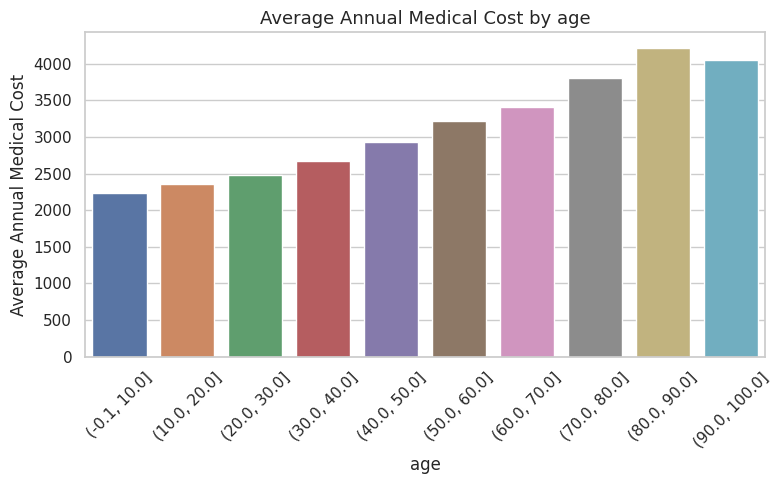

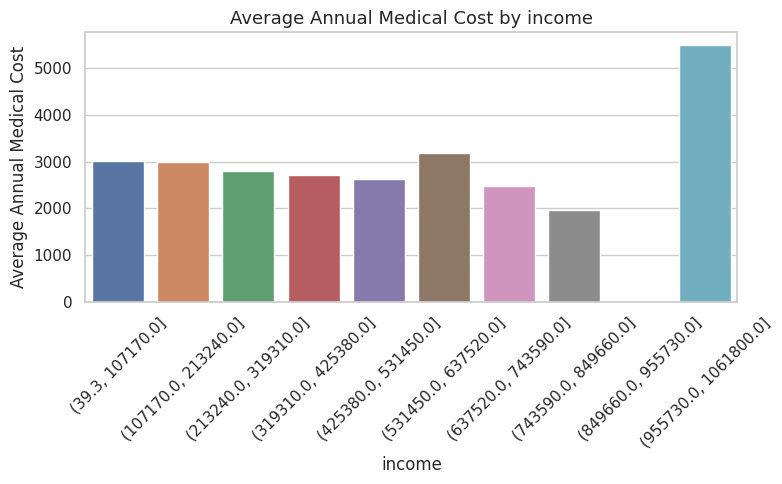

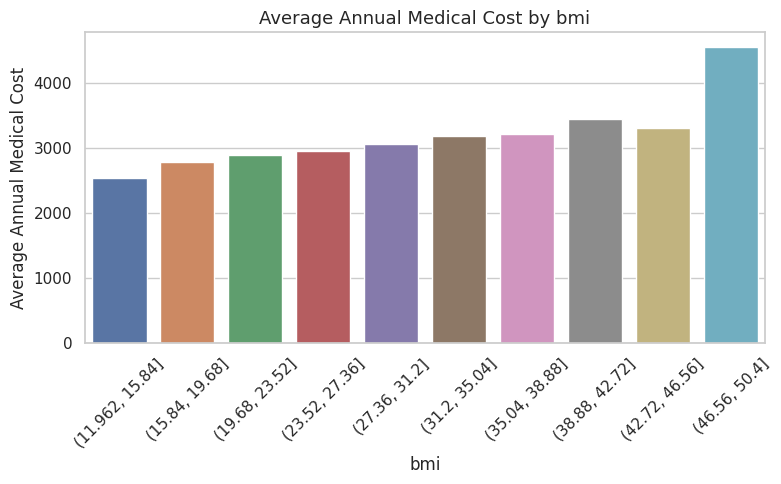

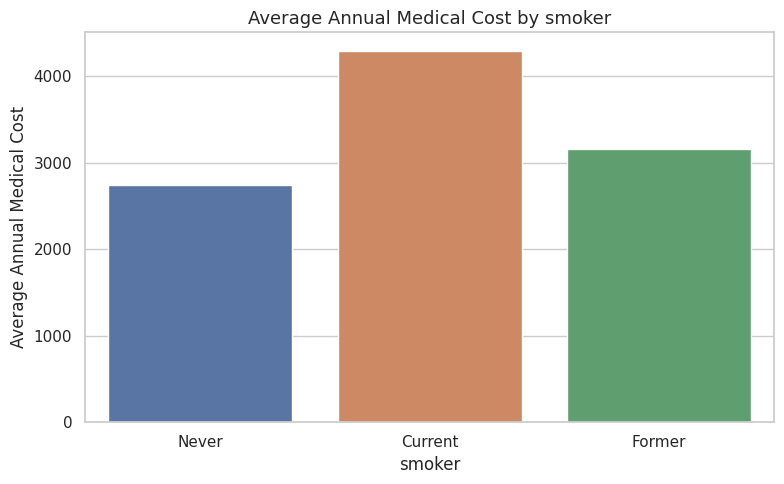

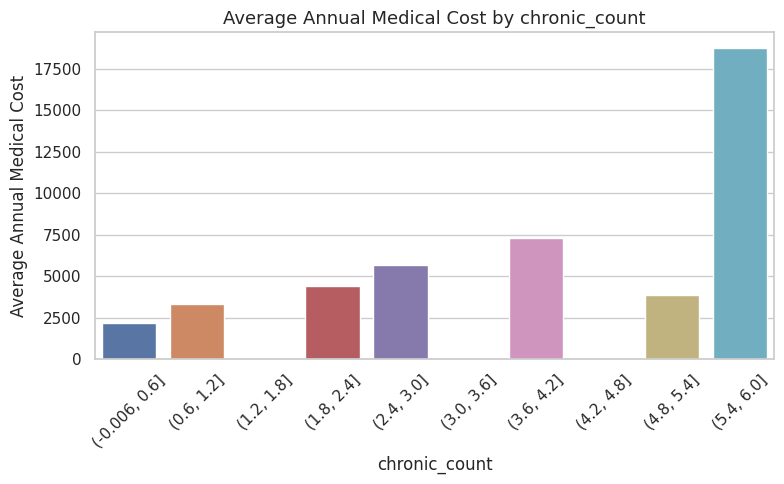

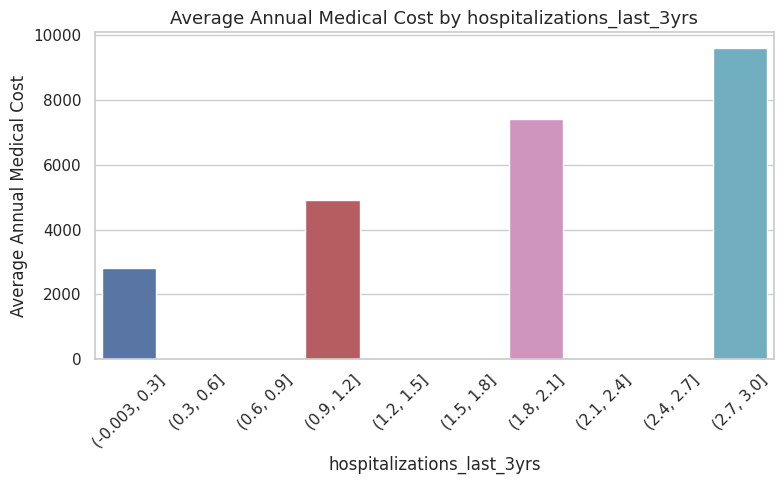

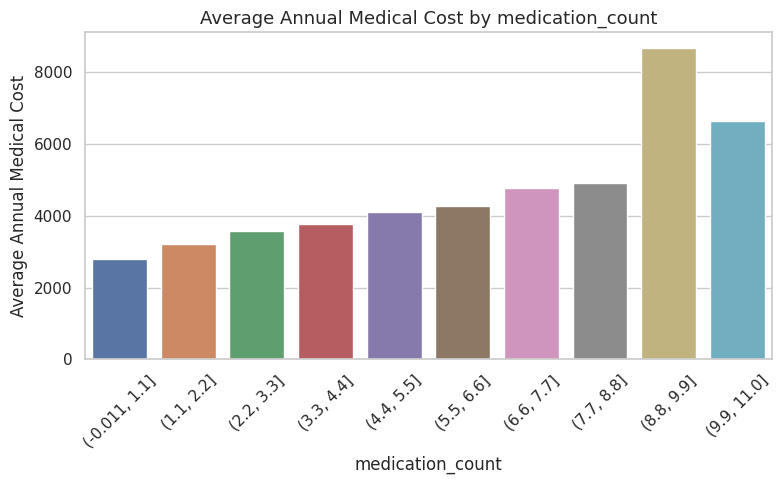

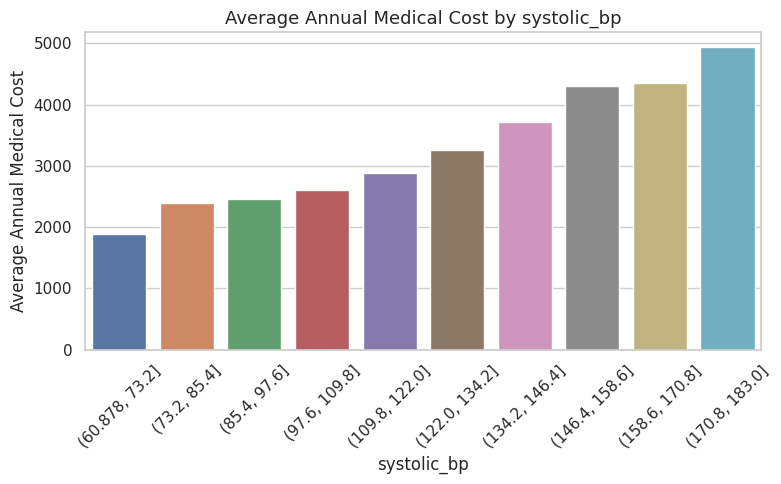

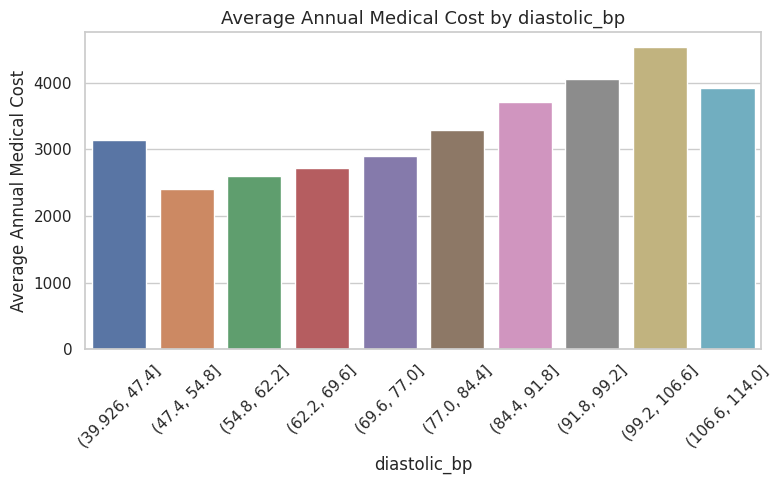

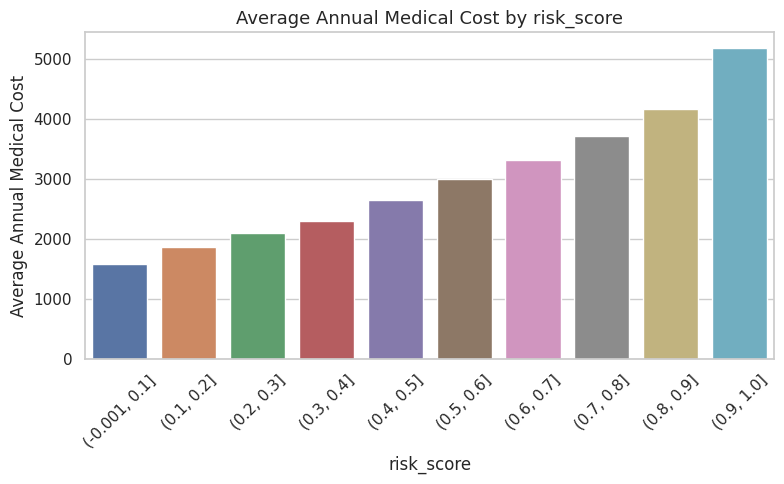

In [4]:
sns.set(style="whitegrid")

important_columns = [
    'age', 'income', 'bmi', 'smoker', 'chronic_count',
    'hospitalizations_last_3yrs', 'medication_count', 
    'systolic_bp', 'diastolic_bp', 'risk_score'
]
for col in important_columns:
    plt.figure(figsize=(8, 5))
    
    if df[col].dtype == 'object':
        # For categorical columns (e.g., smoker)
        sns.barplot(x=col, y='annual_medical_cost', data=df, estimator='mean', ci=None)
    else:
        # For numerical columns - bin them for better visualization
        df_temp = df.copy()
        df_temp[col] = pd.cut(df_temp[col], bins=10)
        sns.barplot(x=col, y='annual_medical_cost', data=df_temp, estimator='mean', ci=None)
        plt.xticks(rotation=45)

    plt.title(f'Average Annual Medical Cost by {col}', fontsize=13)
    plt.xlabel(col)
    plt.ylabel('Average Annual Medical Cost')
    plt.tight_layout()
    plt.show()


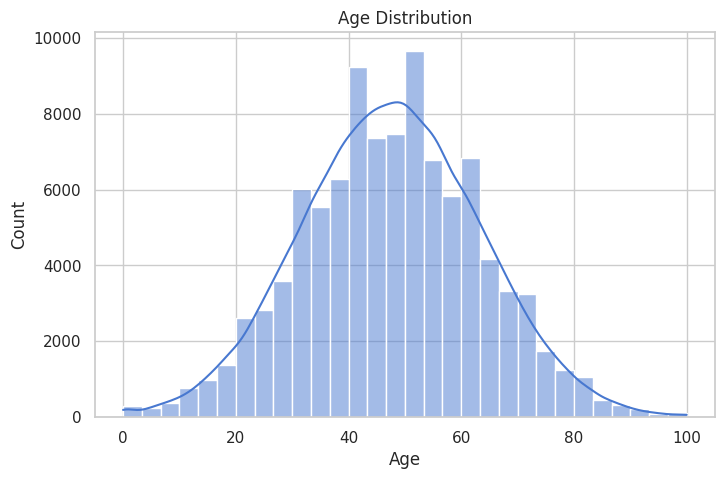

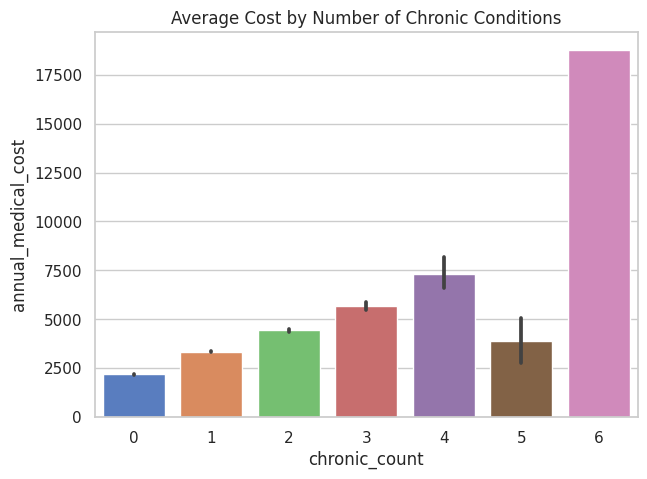

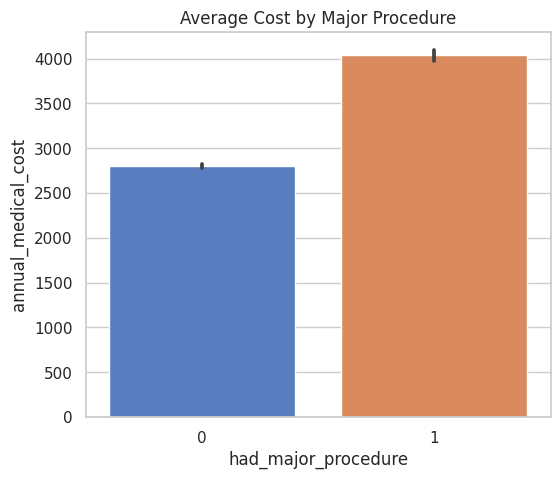

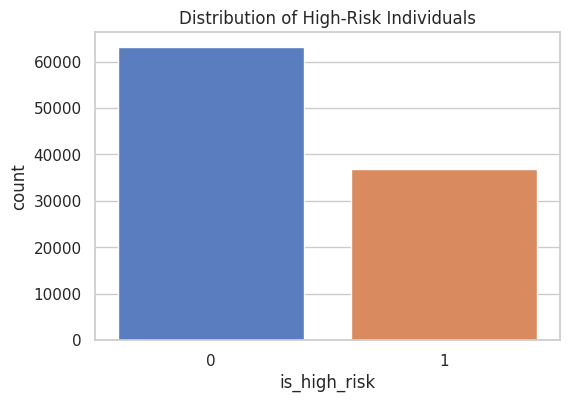

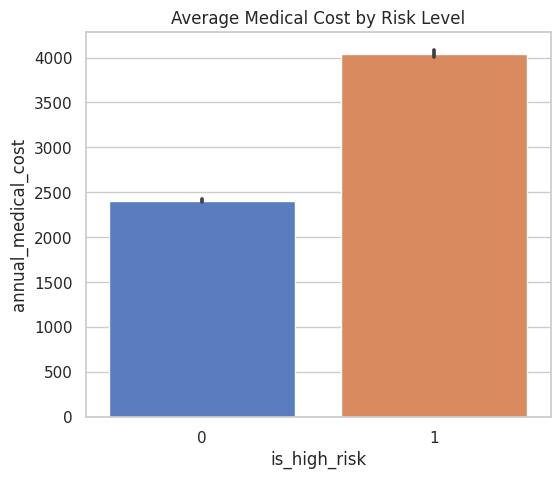

In [5]:
sns.set(style="whitegrid", palette="muted")

plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(7,5))
sns.barplot(x='chronic_count', y='annual_medical_cost', data=df, estimator='mean')
plt.title('Average Cost by Number of Chronic Conditions')
plt.show()

plt.figure(figsize=(6,5))
sns.barplot(x='had_major_procedure', y='annual_medical_cost', data=df)
plt.title('Average Cost by Major Procedure')
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='is_high_risk', data=df)
plt.title('Distribution of High-Risk Individuals')
plt.show()

plt.figure(figsize=(6,5))
sns.barplot(x='is_high_risk', y='annual_medical_cost', data=df)
plt.title('Average Medical Cost by Risk Level')
plt.show()


In [6]:
print(df.info())
print(df.describe())
print(df.shape)
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

person_id                          0
age                                0
sex                                0
region                             0
urban_rural                        0
income                             0
education                          0
marital_status                     0
employment_status                  0
household_size                     0
dependents                         0
bmi                                0
smoker                             0
alcohol_freq                   30083
visits_last_year                   0
hospitalizations_last_3yrs         0
days_hospitalized_last_3yrs        0
medication_count                   0
systolic_bp                        0
diastolic_bp                       0
ldl                                0
hba1c                              0
plan_type                          0
network_tier                       0
deductible                         0
copay                              0
policy_term_years                  0
p

In [7]:
df['alcohol_freq'].fillna(df['alcohol_freq'].mode()[0], inplace=True)
df.drop(columns=['person_id'], inplace=True)

In [8]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

def feature_engineering(data):
    data = data.copy()

    bins = [0, 18, 35, 50, 65, 100]
    labels = ['Child', 'Young Adult', 'Adult', 'Middle-aged', 'Senior']
    data['age_group'] = pd.cut(data['age'], bins=bins, labels=labels, right=False)

    data['dependency_ratio'] = data['dependents'] / (data['household_size'] + 1)

    proc_cols = [col for col in data.columns if 'proc_' in col]
    data['total_procedures'] = data[proc_cols].sum(axis=1)

    data['bmi_category'] = pd.cut(
        data['bmi'], bins=[0,18.5,24.9,29.9,100],
        labels=['Underweight','Normal','Overweight','Obese']
    )

    data['cost_premium_ratio'] = data['annual_medical_cost'] / (data['annual_premium'] + 1)
    
    return data

In [9]:
train_df = feature_engineering(train_df)
test_df = feature_engineering(test_df)

cat_cols = ['sex', 'region', 'urban_rural', 'education', 'marital_status',
            'employment_status', 'smoker', 'alcohol_freq', 'plan_type',
            'network_tier', 'age_group', 'bmi_category']

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))
    le_dict[col] = le

num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
train_df[num_cols] = scaler.fit_transform(train_df[num_cols])
test_df[num_cols] = scaler.transform(test_df[num_cols])

X_train = train_df.drop(columns=['annual_medical_cost'] )
y_train = train_df['annual_medical_cost']

X_test = test_df.drop(columns=['annual_medical_cost'])
y_test = test_df['annual_medical_cost']

re = RandomForestRegressor(n_estimators=100, random_state=42)
re.fit(X_train, y_train)
y_pred = re.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Performance Metrics:")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

Model Performance Metrics:
R² Score: 0.9984
Mean Absolute Error: 0.00
Root Mean Squared Error: 0.04
